In [24]:
#cell 1
#import all the needed tools
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_epochs = 5
batch_size = 64
learning_rate = 0.001
num_classes = 10

Using device: cuda


In [25]:
#cell 2
#for the dataset and the processing

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

#download the training part of CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)

#download the testing part of CIFAR-10
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

#turn datasets into batches
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

#checking the sizes
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 50000
Test size: 10000


In [26]:
#cell 3 - Plain CNN-18 model

class PlainBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super(PlainBlock, self).__init__()

    self.block = nn.Sequential(
      nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(inplace=True),
      nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.block(x)

class PlainCNN18(nn.Module):
  def __init__(self, num_classes=10):
    super(PlainCNN18, self).__init__()

    # first layer
    self.conv1 = nn.Sequential(
      nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True)
    )

    # 4 stages, each stage has 2 blocks, each block has 2 conv layers
    # total conv layers: 1 first conv + 16 convs in blocks = 17 conv layers
    # final linear layer = 18th learnable layer

    self.layer1 = nn.Sequential(
      PlainBlock(64, 64, stride=1),
      PlainBlock(64, 64, stride=1)
   )

    self.layer2 = nn.Sequential(
      PlainBlock(64, 128, stride=2),
      PlainBlock(128, 128, stride=1)
    )

    self.layer3 = nn.Sequential(
      PlainBlock(128, 256, stride=2),
      PlainBlock(256, 256, stride=1)
    )

    self.layer4 = nn.Sequential(
      PlainBlock(256, 512, stride=2),
      PlainBlock(512, 512, stride=1)
    )

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(512, num_classes)

  def forward(self, x):
    x = self.conv1(x)
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.fc(x)
    return x


In [27]:
#cell 4 - ResNet-18 model

resnet18 = torchvision.models.resnet18(weights=None)
#resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

resnet18.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False) #change the first convolution layer to better fit the dataset.
resnet18.maxpool = nn.Identity()
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes) #change the final output layer so the model predicts 10 classes.

In [28]:
#cell 5 - training and evaluation function helpers

def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0
  for images, labels in loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  return running_loss / len(loader)



def evaluate_model(model, loader, criterion, device):
  model.eval()
  running_loss = 0.0
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)
      running_loss += loss.item()
      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())
    avg_loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_labels, all_preds



def train_model(model, train_loader, test_loader, num_epochs, learning_rate, device):
  model = model.to(device)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  train_losses = []
  test_losses = []
  test_accuracies = []
  for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = evaluate_model(model, test_loader, criterion, device)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
  return model, train_losses, test_losses, test_accuracies




def get_final_metrics(model, loader, device):
  model.eval()
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      outputs = model(images)
      _, preds = torch.max(outputs, 1)
      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.numpy())
  acc = accuracy_score(all_labels, all_preds)
  precision = precision_score(all_labels, all_preds, average='macro')
  recall = recall_score(all_labels, all_preds, average='macro')
  f1 = f1_score(all_labels, all_preds, average='macro')
  return acc, precision, recall, f1, all_labels, all_preds

In [29]:
#cell 6 - train plain CNN
plain_cnn = PlainCNN18(num_classes=num_classes)

plain_cnn, plain_train_losses, plain_test_losses, plain_test_accuracies = train_model(
    plain_cnn, train_loader, test_loader, num_epochs, learning_rate, device
)

Epoch [1/5] | Train Loss: 1.7798 | Test Loss: 1.5281 | Test Acc: 0.4165
Epoch [2/5] | Train Loss: 1.4054 | Test Loss: 1.4143 | Test Acc: 0.4982
Epoch [3/5] | Train Loss: 1.1567 | Test Loss: 1.1856 | Test Acc: 0.5807
Epoch [4/5] | Train Loss: 0.9982 | Test Loss: 0.9881 | Test Acc: 0.6556
Epoch [5/5] | Train Loss: 0.8773 | Test Loss: 0.8868 | Test Acc: 0.6885


In [30]:
#cell 7 - train ResNet
resnet18_model = resnet18

resnet18_model, resnet_train_losses, resnet_test_losses, resnet_test_accuracies = train_model(
    resnet18_model, train_loader, test_loader, num_epochs, learning_rate, device
)

Epoch [1/5] | Train Loss: 1.3594 | Test Loss: 1.0773 | Test Acc: 0.6197
Epoch [2/5] | Train Loss: 0.8776 | Test Loss: 0.8366 | Test Acc: 0.7107
Epoch [3/5] | Train Loss: 0.6810 | Test Loss: 0.6958 | Test Acc: 0.7665
Epoch [4/5] | Train Loss: 0.5746 | Test Loss: 0.6139 | Test Acc: 0.7867
Epoch [5/5] | Train Loss: 0.4950 | Test Loss: 0.5098 | Test Acc: 0.8289



Final Results
--------------------------------------------------
Plain CNN-18
Accuracy : 0.6885
Precision: 0.7183
Recall   : 0.6885
F1-score : 0.6947

ResNet-18
Accuracy : 0.8289
Precision: 0.8398
Recall   : 0.8289
F1-score : 0.8301


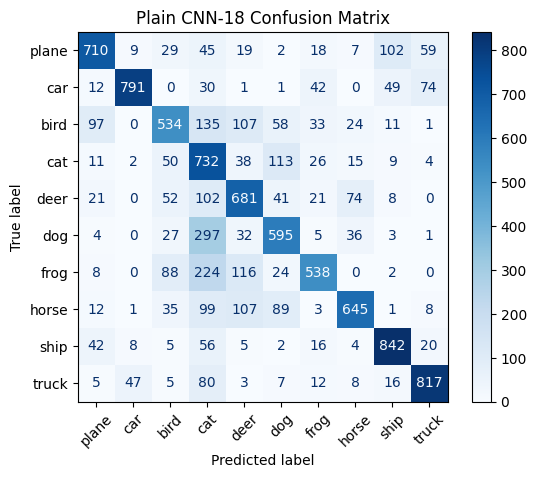

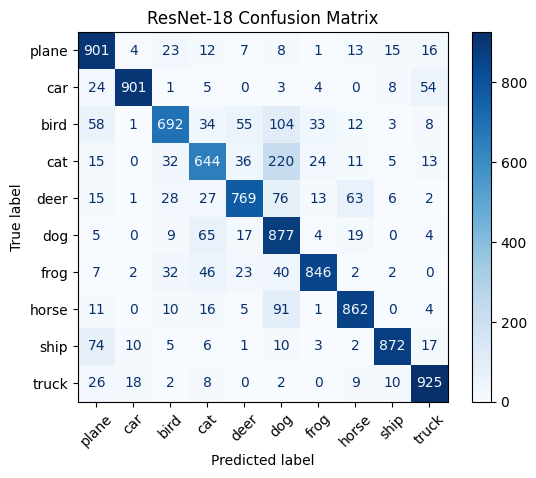

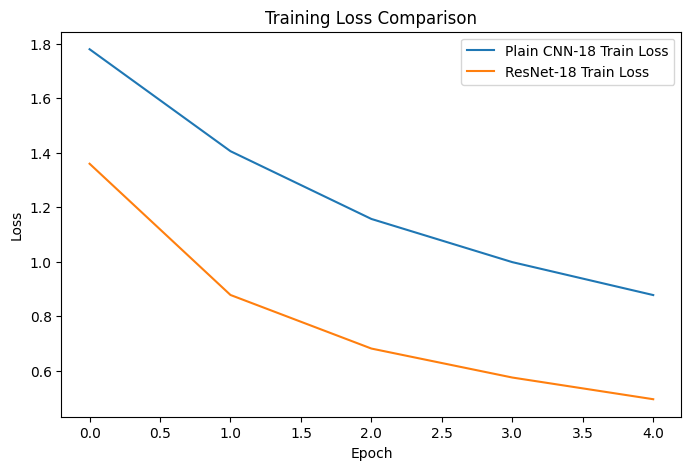

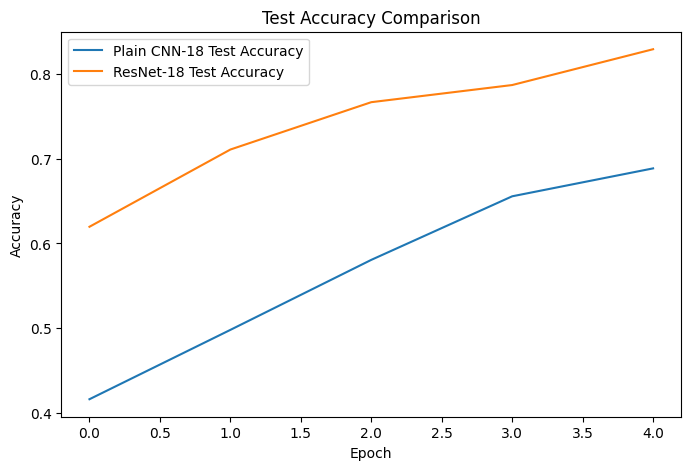


Final Comparison Summary
--------------------------------------------------
Model          Accuracy    Precision   Recall      F1-score    
Plain CNN-18   0.6885      0.7183      0.6885      0.6947      
ResNet-18      0.8289      0.8398      0.8289      0.8301      


In [31]:
#cell 8 - final results and plots

plain_acc, plain_precision, plain_recall, plain_f1, plain_labels, plain_preds = get_final_metrics(
    plain_cnn, test_loader, device
)

resnet_acc, resnet_precision, resnet_recall, resnet_f1, resnet_labels, resnet_preds = get_final_metrics(
    resnet18_model, test_loader, device
)

print("\nFinal Results")
print("-" * 50)
print("Plain CNN-18")
print(f"Accuracy : {plain_acc:.4f}")
print(f"Precision: {plain_precision:.4f}")
print(f"Recall   : {plain_recall:.4f}")
print(f"F1-score : {plain_f1:.4f}")

print("\nResNet-18")
print(f"Accuracy : {resnet_acc:.4f}")
print(f"Precision: {resnet_precision:.4f}")
print(f"Recall   : {resnet_recall:.4f}")
print(f"F1-score : {resnet_f1:.4f}")

# confusion matrix - Plain CNN
cm_plain = confusion_matrix(plain_labels, plain_preds)
disp_plain = ConfusionMatrixDisplay(confusion_matrix=cm_plain, display_labels=classes)
disp_plain.plot(cmap='Blues', xticks_rotation=45)
plt.title("Plain CNN-18 Confusion Matrix")
plt.show()

# confusion matrix - ResNet
cm_resnet = confusion_matrix(resnet_labels, resnet_preds)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=classes)
disp_resnet.plot(cmap='Blues', xticks_rotation=45)
plt.title("ResNet-18 Confusion Matrix")
plt.show()

# training loss plot
plt.figure(figsize=(8, 5))
plt.plot(plain_train_losses, label='Plain CNN-18 Train Loss')
plt.plot(resnet_train_losses, label='ResNet-18 Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.show()

# test accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(plain_test_accuracies, label='Plain CNN-18 Test Accuracy')
plt.plot(resnet_test_accuracies, label='ResNet-18 Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy Comparison')
plt.legend()
plt.show()

# final summary
print("\nFinal Comparison Summary")
print("-" * 50)
print(f"{'Model':<15}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1-score':<12}")
print(f"{'Plain CNN-18':<15}{plain_acc:<12.4f}{plain_precision:<12.4f}{plain_recall:<12.4f}{plain_f1:<12.4f}")
print(f"{'ResNet-18':<15}{resnet_acc:<12.4f}{resnet_precision:<12.4f}{resnet_recall:<12.4f}{resnet_f1:<12.4f}")